# Movie Industry Exploratory Data Analysis

This project analyzes a movie dataset to understand the factors that influence movie success. The analysis focuses on budgets, box office collections, ratings, genres, countries, directors, and actors to identify patterns and generate business insights.

# Import Required Libraries

The libraries used in this project help with data manipulation, analysis, and visualization.

In [153]:
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

# Load Dataset

The dataset is loaded into a pandas DataFrame for analysis and visualization.

In [154]:
path = kagglehub.dataset_download("mjshubham21/movie-dataset-for-analytics-and-visualization")
dataset_name = os.listdir(path)[0]
url = f"{path}/{dataset_name}"
df = pd.read_csv(url)
df

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999994,999995,He anyone,Action,2011,14-09-2011,China,648176.38,1075869.51,2624306.41,170212.67,614079.92,4.8,58,12664,586,Nathan Bolton,Stephanie Moore
999995,999996,Single yourself sister collection,Horror,1982,27-08-1982,USA,657167.15,1046949.86,2164587.12,119899.27,564950.72,7.3,83,622,2327,David Lee,Tracy Klein
999996,999997,Old economic,Documentary,1993,12-02-1993,USA,29914685.15,30619499.73,57774787.73,6331667.63,18136941.88,4.1,32,100,1394,Jeremy Davis,Lynn Pierce
999997,999998,My itself and leave,Horror,2013,11-11-2013,India,1382498.55,3168114.87,5567631.38,438945.44,1703606.02,4.3,23,2337,105,Melanie Olson,Melissa Mcgee


# Initial Data Exploration

Before performing any analysis, it is important to understand the structure of the dataset.

This includes:

- Number of rows and columns
- Column names
- Data types
- Summary statistics
- Sample records

In [155]:
df.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [156]:
#actor with most movies
#actor with highest box office collection
#director with high imdb avg rating
#director with high rotentomatoscore rating
#top movies by global boxoffice
#top boxoffice movie by genre
#top boxoffice movie by country
#top opening movie by genre
#top opening movie by country
#budget vs global boxoffice relation with hue as genre
#budget vs global boxoffice relation with hue as country
#rating vs global boxoffice relation with huge as genre
#rating vs global boxoffice relation with huge as country
#genre vs global boxoffice relation bar chart
#country vs global boxoffice relation bar chart
#rotentomato score vs global boxoffice with hue as genre
#rotentomato score vs global boxoffice with hue as country

In [157]:
df.tail()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
999994,999995,He anyone,Action,2011,14-09-2011,China,648176.38,1075869.51,2624306.41,170212.67,614079.92,4.8,58,12664,586,Nathan Bolton,Stephanie Moore
999995,999996,Single yourself sister collection,Horror,1982,27-08-1982,USA,657167.15,1046949.86,2164587.12,119899.27,564950.72,7.3,83,622,2327,David Lee,Tracy Klein
999996,999997,Old economic,Documentary,1993,12-02-1993,USA,29914685.15,30619499.73,57774787.73,6331667.63,18136941.88,4.1,32,100,1394,Jeremy Davis,Lynn Pierce
999997,999998,My itself and leave,Horror,2013,11-11-2013,India,1382498.55,3168114.87,5567631.38,438945.44,1703606.02,4.3,23,2337,105,Melanie Olson,Melissa Mcgee
999998,999999,Congress federal policy,Drama,1995,09-08-1995,USA,7655641.81,18626549.48,34908325.31,4342391.46,10764341.98,6.6,60,24528,872,Albert Phillips,Samantha Sanders


In [158]:
df.shape

(999999, 17)

In [159]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='str')

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               999999 non-null  int64  
 1   Title                 999999 non-null  str    
 2   Genre                 999999 non-null  str    
 3   ReleaseYear           999999 non-null  int64  
 4   ReleaseDate           999999 non-null  str    
 5   Country               999999 non-null  str    
 6   BudgetUSD             999999 non-null  float64
 7   US_BoxOfficeUSD       999999 non-null  float64
 8   Global_BoxOfficeUSD   999999 non-null  float64
 9   Opening_Day_SalesUSD  999999 non-null  float64
 10  One_Week_SalesUSD     999999 non-null  float64
 11  IMDbRating            999999 non-null  float64
 12  RottenTomatoesScore   999999 non-null  int64  
 13  NumVotesIMDb          999999 non-null  int64  
 14  NumVotesRT            999999 non-null  int64  
 15  Director   

In [270]:
df["ReleaseDate"] = pd.to_datetime(df["ReleaseDate"])

In [161]:
#date str to date
#movieID is unnecessary

In [162]:
df.describe()

,MovieID,ReleaseYear,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,999999.000000,999999.000000,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000,999999.000000,999999.000000,999999.000000
mean,500000.000000,1998.001220,9.802824e+06,1.496163e+07,2.720625e+07,2.992745e+06,7.483442e+06,6.494788,64.776426,9137.184011,2031.880340
std,288674.990257,19.260863,2.249421e+07,3.879403e+07,6.954294e+07,8.132438e+06,1.955337e+07,1.485606,17.592474,24922.362780,8433.380602
min,1.000000,1950.000000,1.000000e+05,4.002547e+04,1.000000e+05,4.050470e+03,1.650742e+04,1.000000,0.000000,100.000000,50.000000
25%,250000.500000,1984.000000,1.190511e+06,1.489805e+06,2.762370e+06,2.790262e+05,7.383145e+05,5.500000,53.000000,1083.000000,119.000000
50%,500000.000000,2001.000000,3.265790e+06,4.388876e+06,8.090223e+06,8.387221e+05,2.179436e+06,6.500000,65.000000,2983.000000,405.000000
75%,749999.500000,2014.000000,9.002791e+06,1.287606e+07,2.355245e+07,2.510360e+06,6.415143e+06,7.500000,77.000000,8192.000000,1360.000000
max,999999.000000,2025.000000,3.000000e+08,1.018198e+09,1.499497e+09,2.957511e+08,5.795551e+08,10.000000,100.000000,1000000.000000,500000.000000


# Duplicate Records Check

Duplicate records may create bias in the analysis.

We check whether duplicate rows exist and remove them if necessary.

In [163]:
df.duplicated().sum()

np.int64(0)

# Missing Value Analysis

Missing values can affect the quality of analysis and lead to incorrect conclusions.

In this section, we identify missing values and determine how they should be handled.

In [164]:
df.isnull().sum()

MovieID                 0
Title                   0
Genre                   0
ReleaseYear             0
ReleaseDate             0
Country                 0
BudgetUSD               0
US_BoxOfficeUSD         0
Global_BoxOfficeUSD     0
Opening_Day_SalesUSD    0
One_Week_SalesUSD       0
IMDbRating              0
RottenTomatoesScore     0
NumVotesIMDb            0
NumVotesRT              0
Director                0
LeadActor               0
dtype: int64

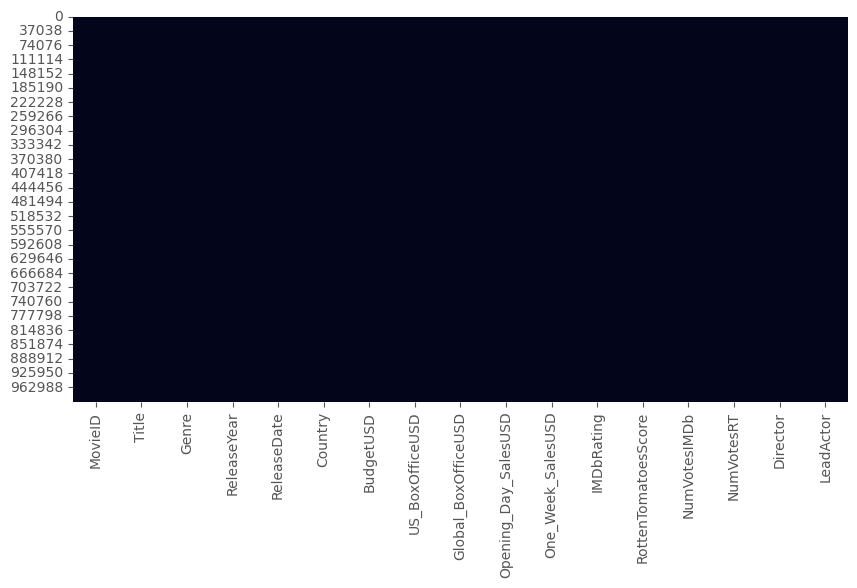

In [165]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [166]:
#no null values

# Numerical Feature Analysis

This section examines the distribution of important numerical variables such as budget, box office collections, and ratings.

Understanding these distributions helps identify skewness and potential outliers.

In [167]:
films_by_genre = df["Genre"].value_counts().sort_values(ascending=True)
print(films_by_genre)

Genre
Sci-Fi          49802
Documentary     50114
Horror         100010
Romance        100021
Thriller       100071
Action         150131
Comedy         199832
Drama          250018
Name: count, dtype: int64


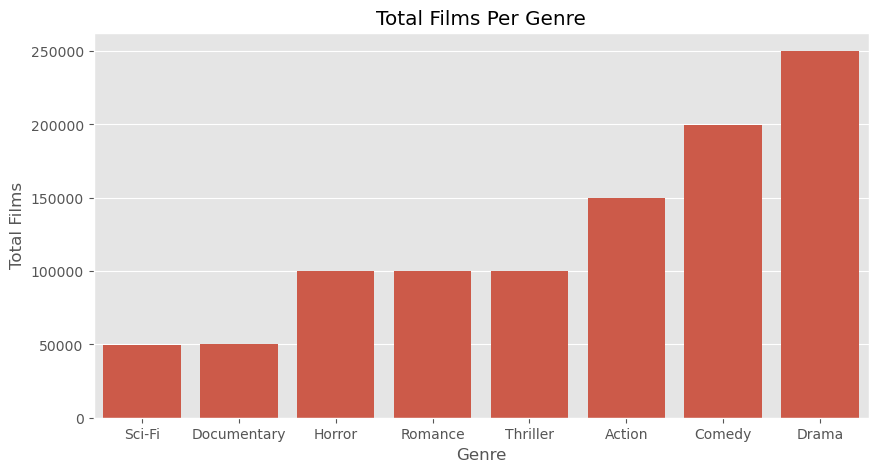

In [168]:
plt.figure(figsize=(10,5))
sns.barplot(x = films_by_genre.index, y = films_by_genre.values)
plt.ylabel("Total Films")
plt.title("Total Films Per Genre")
plt.show()

In [169]:
films_per_country = df["Country"].value_counts().sort_values(ascending=True)
print(films_per_country)

Country
South Korea     10186
Germany         20211
Japan           20222
France          30471
Australia       30587
China           30952
Canada          40528
India           50984
UK              51277
USA            714581
Name: count, dtype: int64


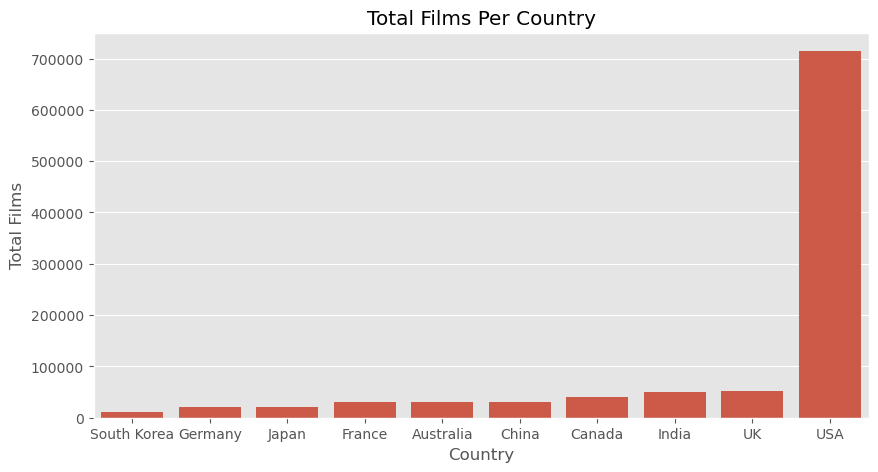

In [170]:
plt.figure(figsize=(10,5))
sns.barplot(x = films_per_country.index, y = films_per_country.values)
plt.ylabel("Total Films")
plt.title("Total Films Per Country")
plt.show()

In [172]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   MovieID               999999 non-null  int64         
 1   Title                 999999 non-null  str           
 2   Genre                 999999 non-null  str           
 3   ReleaseYear           999999 non-null  int64         
 4   ReleaseDate           999999 non-null  datetime64[us]
 5   Country               999999 non-null  str           
 6   BudgetUSD             999999 non-null  float64       
 7   US_BoxOfficeUSD       999999 non-null  float64       
 8   Global_BoxOfficeUSD   999999 non-null  float64       
 9   Opening_Day_SalesUSD  999999 non-null  float64       
 10  One_Week_SalesUSD     999999 non-null  float64       
 11  IMDbRating            999999 non-null  float64       
 12  RottenTomatoesScore   999999 non-null  int64         
 13  NumVotesIM

In [173]:
df.head(5)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,2003-09-28,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,1988-02-14,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,1971-11-02,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,1998-08-06,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,2021-12-17,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [174]:
df.groupby("Genre")["BudgetUSD"].agg("sum").sort_values(ascending=False)

Genre
Drama          2.448712e+12
Comedy         1.963654e+12
Action         1.443621e+12
Thriller       9.894555e+11
Horror         9.880415e+11
Romance        9.846272e+11
Documentary    4.976874e+11
Sci-Fi         4.870159e+11
Name: BudgetUSD, dtype: float64

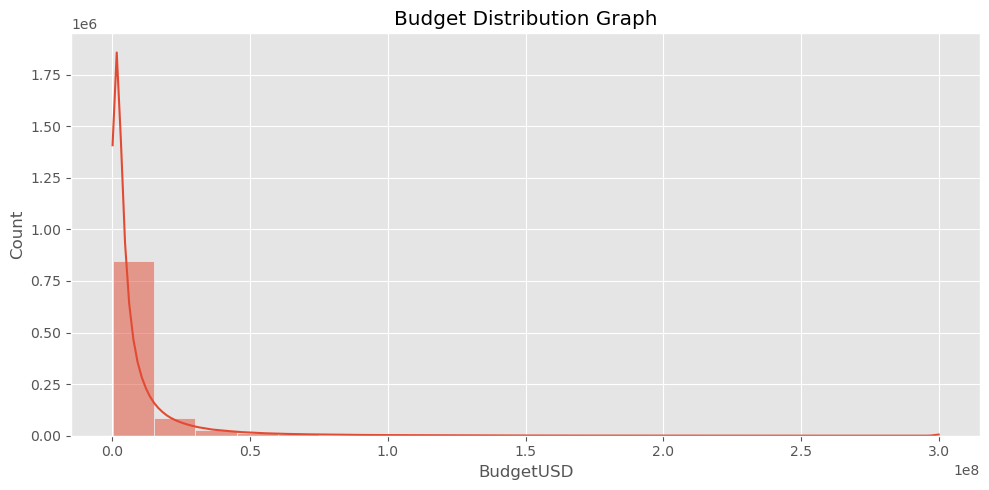

In [175]:
#data distribution
#budget distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df, x = "BudgetUSD",bins=20, kde=True)
plt.title("Budget Distribution Graph")
plt.tight_layout()
plt.show()

In [176]:
#extreme skewness
#options available -> 1) log transformation 2) standardization with z-score 3) normalisation to 0 - 1 range aka min max normalisation
#since the values are of extreme order, lets use log transformation using numpy

# Log Transformation

Some financial variables have highly skewed distributions.

A log transformation is applied to reduce skewness and improve interpretability of the data.

In [177]:
df["new_budget_representation"] = np.log1p(df["BudgetUSD"])

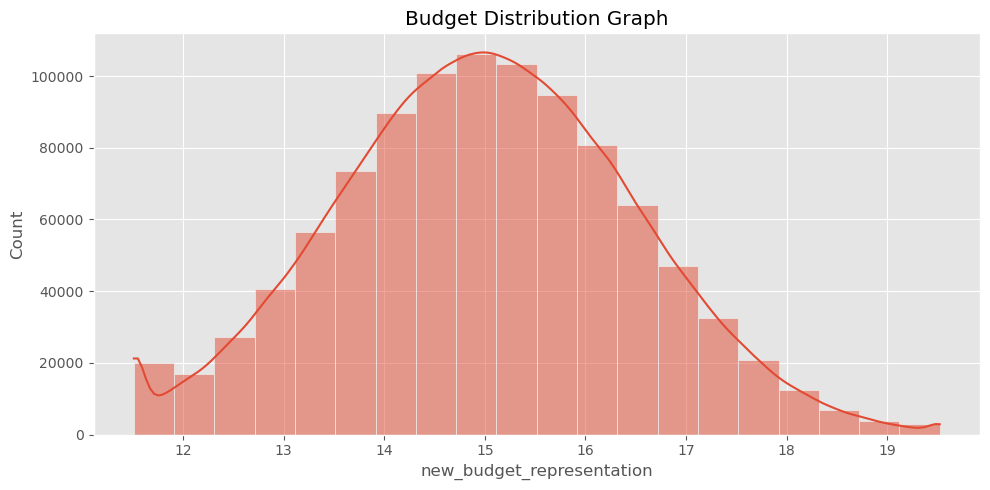

In [178]:
#data distribution after log transformation
plt.figure(figsize=(10,5))
sns.histplot(data=df, x = "new_budget_representation",bins=20, kde=True)
plt.title("Budget Distribution Graph")
plt.tight_layout()
plt.show()

In [179]:
genre_wise_budget = df.groupby("Genre")["new_budget_representation"].agg("sum").sort_values(ascending=True)
print(genre_wise_budget)

Genre
Sci-Fi         7.471249e+05
Documentary    7.520792e+05
Horror         1.500641e+06
Romance        1.500729e+06
Thriller       1.501922e+06
Action         2.251442e+06
Comedy         2.998503e+06
Drama          3.752052e+06
Name: new_budget_representation, dtype: float64


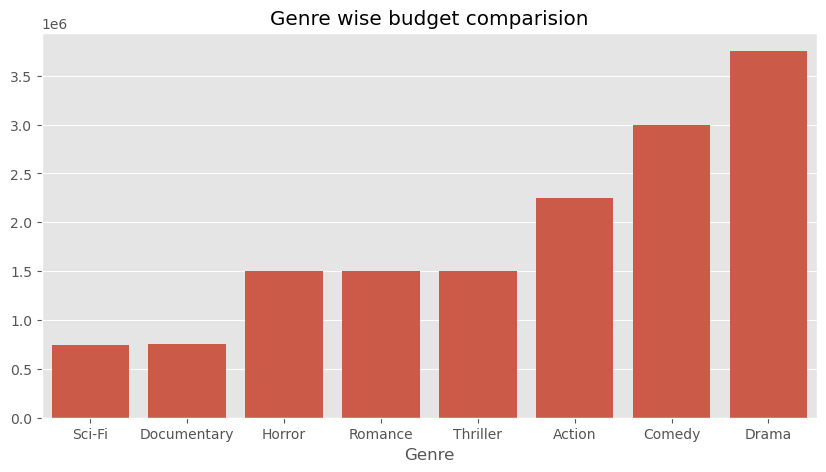

In [180]:
plt.figure(figsize=(10,5))
sns.barplot( x = genre_wise_budget.index, y = genre_wise_budget.values)
plt.title("Genre wise budget comparision")
plt.show()

In [181]:
country_wise_budget = df.groupby("Country")["new_budget_representation"].agg("sum").sort_values(ascending=True)
print(country_wise_budget)

Country
South Korea    1.529046e+05
Japan          3.029575e+05
Germany        3.034145e+05
France         4.572285e+05
Australia      4.588188e+05
China          4.638914e+05
Canada         6.081904e+05
India          7.648732e+05
UK             7.699692e+05
USA            1.072225e+07
Name: new_budget_representation, dtype: float64


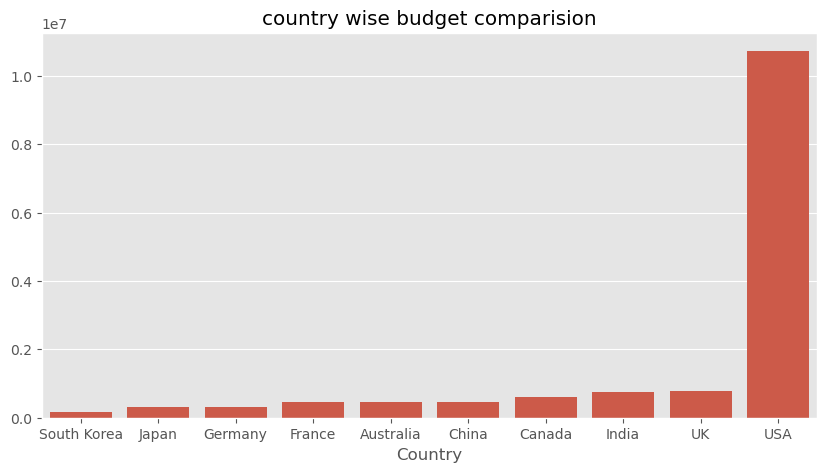

In [182]:
plt.figure(figsize=(10,5))
sns.barplot( x = country_wise_budget.index, y = country_wise_budget.values)
plt.title("country wise budget comparision")
plt.show()

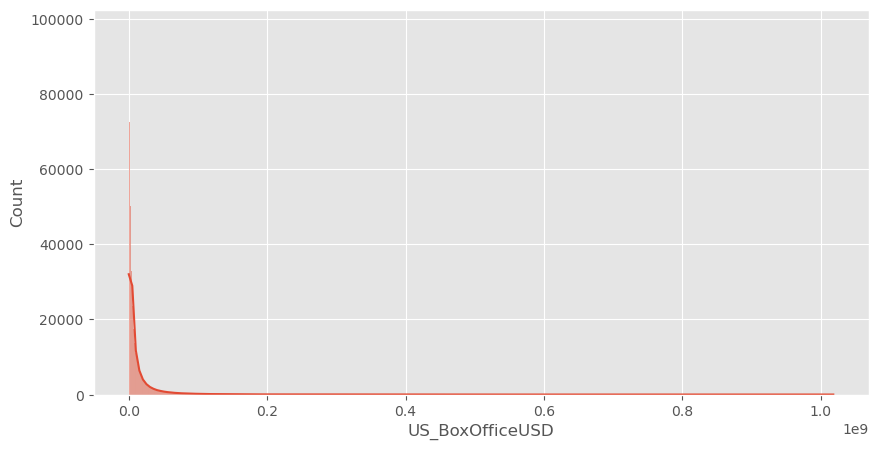

In [183]:
#usboxoffice data distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df, x = "US_BoxOfficeUSD", kde=True)
plt.show()

In [238]:
df["new_usboxoffice_representation"] = np.log1p(df["US_BoxOfficeUSD"])


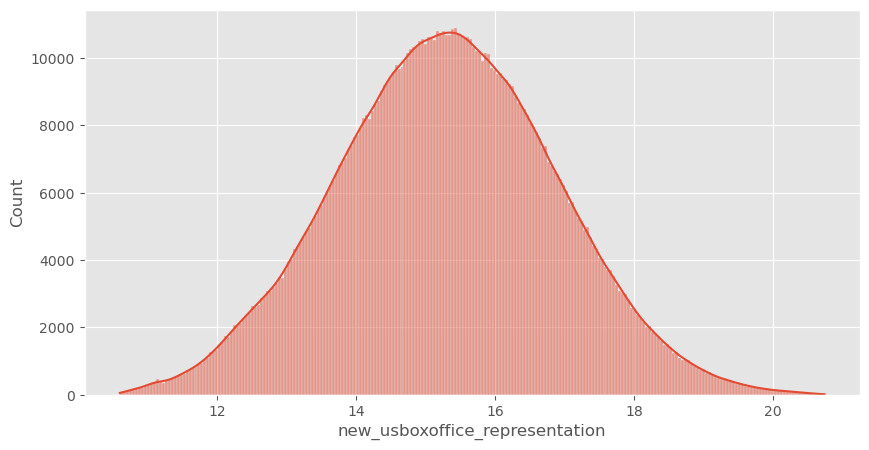

In [239]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x = "new_usboxoffice_representation", kde=True)
plt.show()

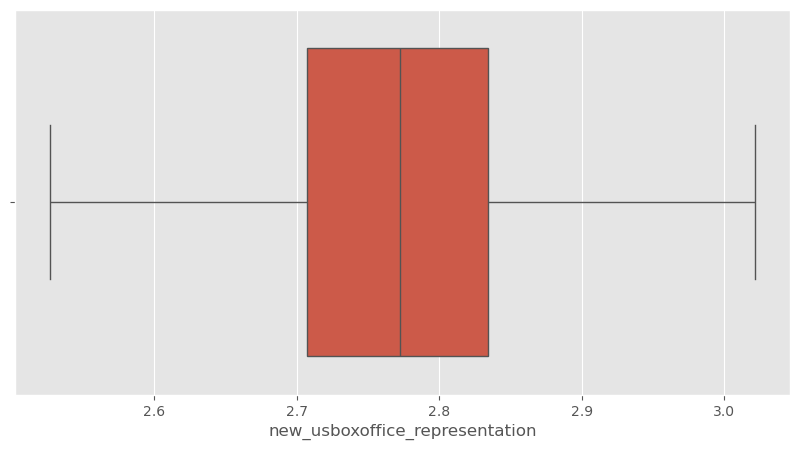

In [186]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x = "new_usboxoffice_representation")
plt.show()

In [187]:
genre_wise_usboxoffice = df.groupby("Genre")["new_usboxoffice_representation"].agg("sum").sort_values(ascending=False)
print(genre_wise_usboxoffice)

Genre
Drama          692225.827393
Comedy         553247.362371
Action         415571.971495
Thriller       277073.314832
Romance        276906.609783
Horror         276880.847210
Documentary    138749.546117
Sci-Fi         137869.431499
Name: new_usboxoffice_representation, dtype: float64


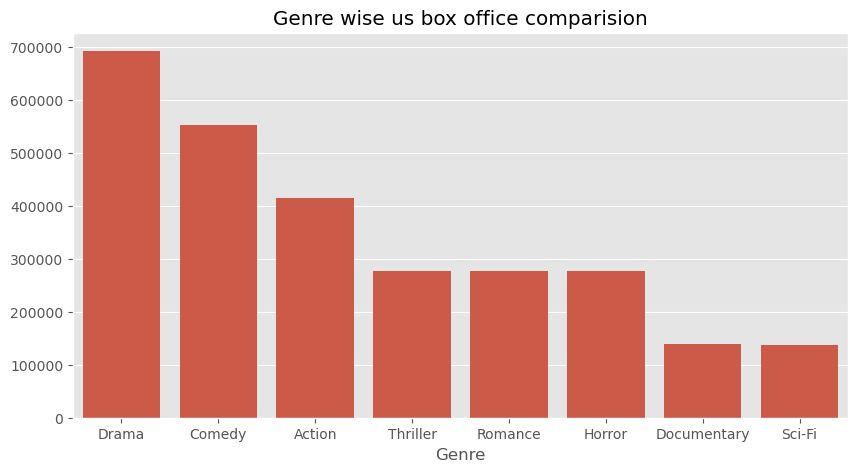

In [188]:
plt.figure(figsize=(10,5))
sns.barplot( x = genre_wise_usboxoffice.index, y = genre_wise_usboxoffice.values)
plt.title("Genre wise us box office comparision")
plt.show()

In [189]:
country_wise_usboxoffice = df.groupby("Country")["new_usboxoffice_representation"].agg("sum").sort_values(ascending=False)
print(country_wise_usboxoffice)

Country
USA            1.978360e+06
UK             1.419971e+05
India          1.411401e+05
Canada         1.122084e+05
China          8.565837e+04
Australia      8.467375e+04
France         8.436136e+04
Germany        5.596429e+04
Japan          5.595621e+04
South Korea    2.820501e+04
Name: new_usboxoffice_representation, dtype: float64


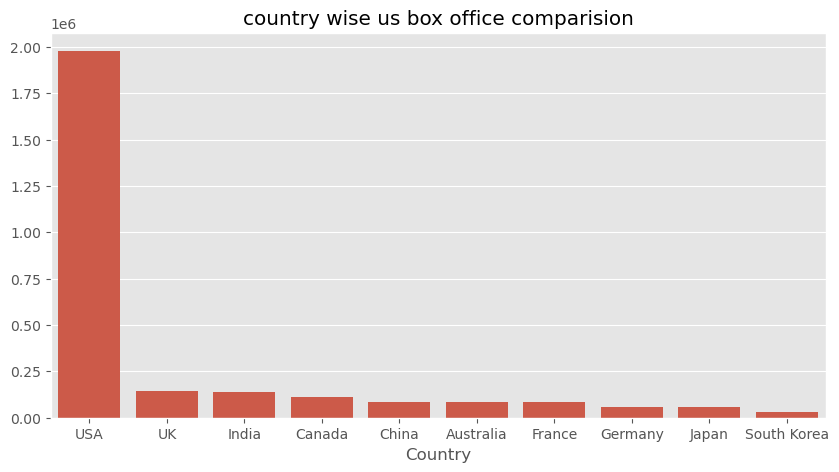

In [190]:
plt.figure(figsize=(10,5))
sns.barplot( x = country_wise_usboxoffice.index, y = country_wise_usboxoffice.values)
plt.title("country wise us box office comparision")
plt.show()

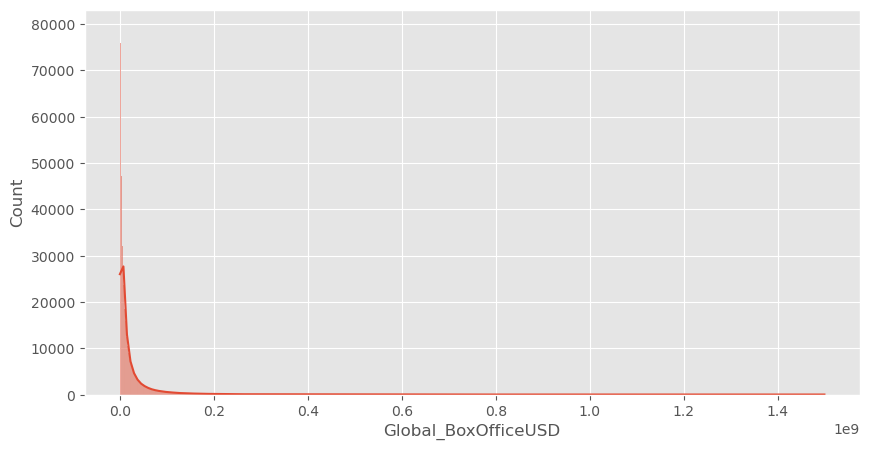

In [191]:
#Global_BoxOfficeUSD
plt.figure(figsize=(10,5))
sns.histplot(data=df, x = "Global_BoxOfficeUSD", kde=True)
plt.show()


In [192]:
df["new_global_boxoffice_representation"] = np.log1p(df["Global_BoxOfficeUSD"])

In [193]:
df["new_global_boxoffice_representation"].head()

0    16.554545
1    15.106871
2    15.784734
3    15.291148
4    14.951103
Name: new_global_boxoffice_representation, dtype: float64

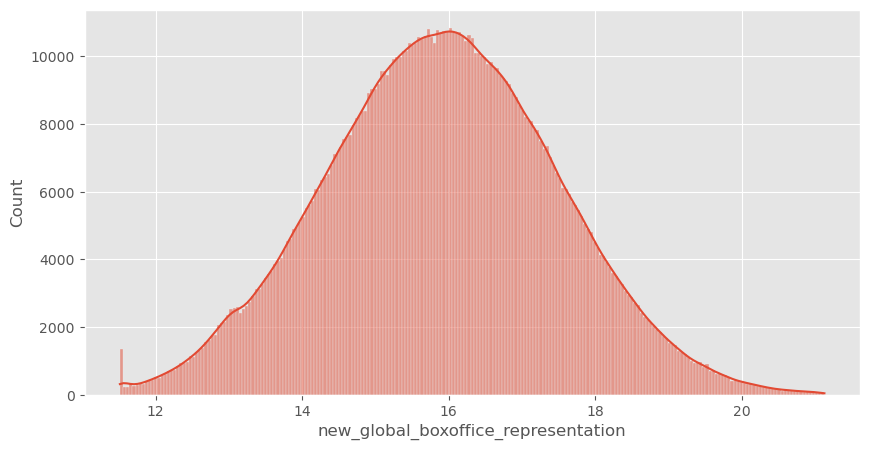

In [194]:
#Global_BoxOfficeUSD
plt.figure(figsize=(10,5))
sns.histplot(data=df, x = "new_global_boxoffice_representation", kde=True)
plt.show()


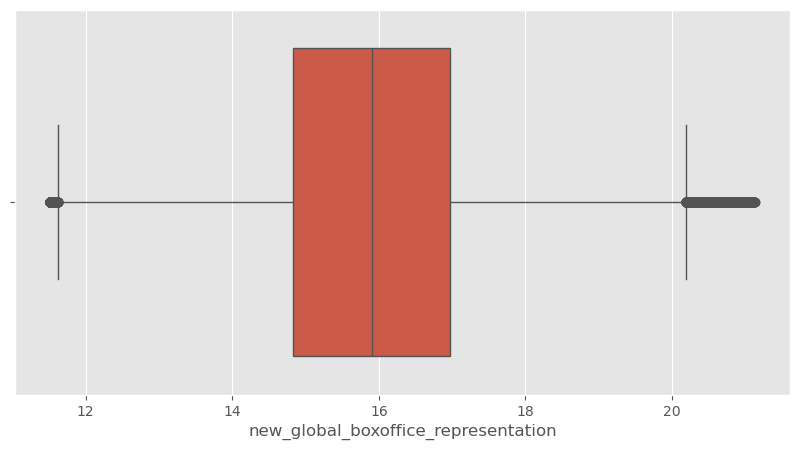

In [195]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x = "new_global_boxoffice_representation")
plt.show()

In [240]:
genre_wise_global_boxoffice = df.groupby("Genre")["Global_BoxOfficeUSD"].agg("sum").sort_values(ascending=True)
country_wise_global_boxoffice = df.groupby("Country")["Global_BoxOfficeUSD"].agg("sum").sort_values(ascending=True)

# Genre Analysis

Different genres attract different audiences and generate varying levels of revenue.

This analysis helps identify the genres that dominate the movie industry.

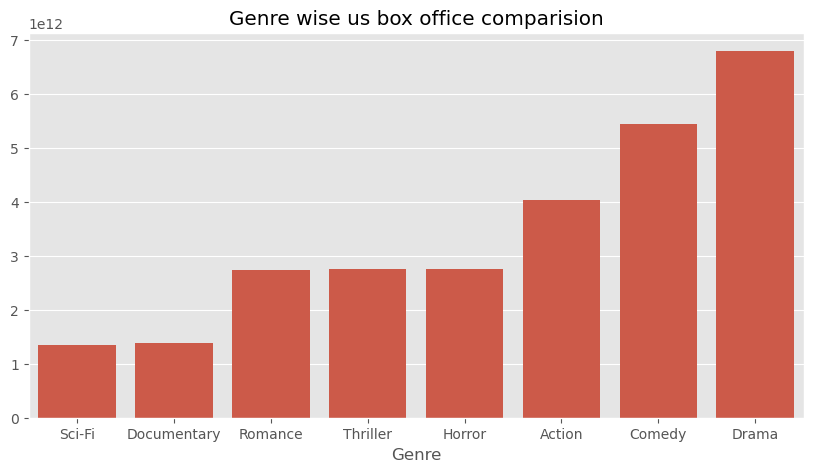

In [241]:
plt.figure(figsize=(10,5))
sns.barplot( x = genre_wise_global_boxoffice.index, y = genre_wise_global_boxoffice.values)
plt.title("Genre wise us box office comparision")
plt.show()

# Country Analysis

Movie production and revenue vary across countries.

This section examines how countries contribute to overall box office performance.

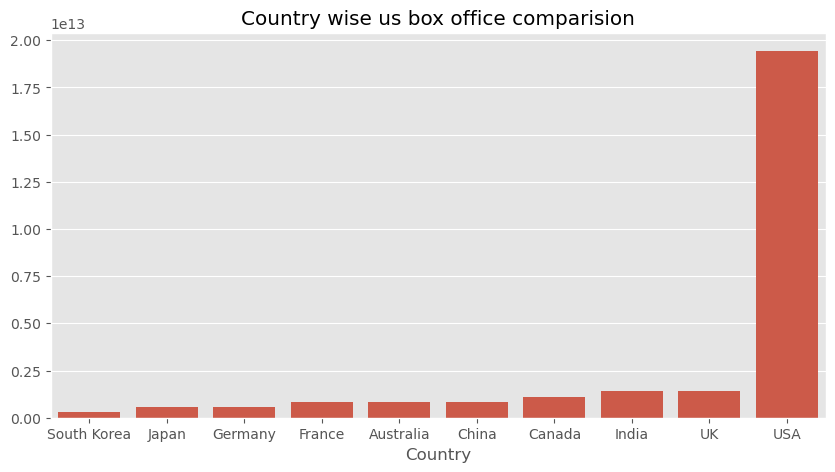

In [242]:
plt.figure(figsize=(10,5))
sns.barplot( x = country_wise_global_boxoffice.index, y = country_wise_global_boxoffice.values)
plt.title("Country wise us box office comparision")
plt.show()

In [ ]:
#actor with most movies  #
#actor with highest box office collection #
#director with high imdb avg rating #
#director with high rotentomatoscore rating #
#top movies by global boxoffice #
#top boxoffice movie by genre #
#top boxoffice movie by country #
#top opening movie by genre #
#top opening movie by country #

In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 20 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   MovieID                              999999 non-null  int64         
 1   Title                                999999 non-null  str           
 2   Genre                                999999 non-null  str           
 3   ReleaseYear                          999999 non-null  int64         
 4   ReleaseDate                          999999 non-null  datetime64[us]
 5   Country                              999999 non-null  str           
 6   BudgetUSD                            999999 non-null  float64       
 7   US_BoxOfficeUSD                      999999 non-null  float64       
 8   Global_BoxOfficeUSD                  999999 non-null  float64       
 9   Opening_Day_SalesUSD                 999999 non-null  float64       
 10  One_Wee

# Actor Analysis

Actors often play an important role in attracting audiences.

This section identifies:

- Actors appearing in the most movies
- Actors associated with the highest box office collections

In [201]:
df.groupby("LeadActor")["MovieID"].agg("count").sort_values(ascending=False).head(5)

LeadActor
Jeffrey Smith      6688
Nathan Nelson      3485
Mark Morris        3467
Michael Gomez      3463
Courtney Butler    3455
Name: MovieID, dtype: int64

In [204]:
df.groupby("LeadActor")["new_global_boxoffice_representation"].agg("sum").sort_values(ascending=False).head(5)

LeadActor
Jeffrey Smith      106480.803704
Nathan Nelson       55487.927371
Mark Morris         55128.226687
Michael Gomez       55037.392936
Joseph Gonzalez     55016.238445
Name: new_global_boxoffice_representation, dtype: float64

# Director Analysis

Directors influence the quality and commercial success of movies.

This analysis identifies directors with the highest average ratings and strongest movie portfolios.

In [205]:
df.groupby("Director")["IMDbRating"].agg("mean").sort_values(ascending=False).head(5)

Director
Carolyn Schwartz            6.543142
Mrs. Hannah Campbell DDS    6.538433
James Miller                6.536948
Chad Koch                   6.533313
Roberto Underwood           6.524989
Name: IMDbRating, dtype: float64

In [206]:
df.groupby("Director")["RottenTomatoesScore"].agg("mean").sort_values(ascending=False).head(5)

Director
Chad Koch                   65.395802
Seth Whitehead              65.257269
Mrs. Hannah Campbell DDS    65.183374
Carolyn Schwartz            65.158881
Diana Davis                 65.127034
Name: RottenTomatoesScore, dtype: float64

In [207]:
df[["Title","Global_BoxOfficeUSD"]].sort_values(by="Global_BoxOfficeUSD",ascending=False).head(5)

,Title,Global_BoxOfficeUSD
220370,Scientist picture,1.499497e+09
334338,Among religious night,1.499468e+09
788782,Happy religious serious citizen,1.496190e+09
970554,Free cup day tree,1.495816e+09
504069,Cut,1.495192e+09


In [213]:
df.loc[df.groupby("Genre")["Global_BoxOfficeUSD"].idxmax()]

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,new_budget_representation,new_usboxoffice_representation,new_global_boxoffice_representation
360671,360672,Item,Action,1954,1954-08-13,USA,300000000.0,654385907.4,1.478332e+09,1.187029e+08,375913714.7,4.3,52,27691,2086,Michael Richards,Thomas Hill,19.519293,3.021366,21.114180
334338,334339,Among religious night,Comedy,2013,2013-04-21,USA,300000000.0,688602564.1,1.499468e+09,1.283525e+08,304409689.2,7.3,73,11072,50,Paul Rogers,George Green,19.519293,3.021366,21.128376
220370,220371,Scientist picture,Documentary,1977,1977-12-13,USA,300000000.0,784819473.5,1.499497e+09,9.973905e+07,375257193.4,5.4,69,244,50,Joshua Baker,Ashley Reeves,19.519293,3.021366,21.128395
970554,970555,Free cup day tree,Drama,1951,1951-03-19,USA,300000000.0,989194085.0,1.495816e+09,2.104888e+08,579555113.2,8.3,93,3959,50,Claudia Smith,Duane Fletcher DDS,19.519293,3.021366,21.125938
825214,825215,Century character consider area,Horror,2005,2005-03-10,USA,300000000.0,991910935.5,1.483664e+09,1.440953e+08,436260039.0,6.4,76,3739,604,Michelle Collins,Dominique Aguirre,19.519293,3.021366,21.117781
31386,31387,Ask man hundred mind,Romance,2023,2023-05-26,Canada,300000000.0,731363295.8,1.465729e+09,1.206206e+08,378919722.7,7.1,72,1010,310,Amber Anderson,Jennifer Cook,19.519293,3.021366,21.105619
788782,788783,Happy religious serious citizen,Sci-Fi,2003,2003-05-27,USA,300000000.0,742962955.7,1.496190e+09,1.349609e+08,424993872.9,6.5,58,2546,12098,Anthony Rowland,Brian Rodriguez,19.519293,3.021366,21.126188
34110,34111,Production five rule,Thriller,2003,2003-12-09,USA,300000000.0,967863965.4,1.493572e+09,1.964184e+08,465486821.8,8.3,89,21106,478,Abigail Robles,John Perry,19.519293,3.021366,21.124436


In [217]:
df.loc[df.groupby("Country")["Global_BoxOfficeUSD"].idxmax()]

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,new_budget_representation,new_usboxoffice_representation,new_global_boxoffice_representation
119415,119416,Enough boy,Thriller,1992,1992-10-26,Australia,300000000.0,668640444.1,1.458425e+09,1.337087e+08,350147699.1,5.3,62,70814,361,Sophia Gomez,Lawrence Thomas,19.519293,3.021366,21.100623
924737,924738,Which team deep,Comedy,2024,2024-01-01,Canada,300000000.0,848957782.1,1.492660e+09,2.522379e+08,474765253.7,6.6,84,8148,3116,Gary Simmons,William Ramirez,19.519293,3.021366,21.123825
924822,924823,Response each,Documentary,2000,2000-05-08,China,300000000.0,698227713.0,1.441172e+09,1.227736e+08,372501217.0,5.0,46,5694,1492,Seth Whitehead,Shawn Washington,19.519293,3.021366,21.088723
827614,827615,Later suffer unit,Action,2009,2009-02-21,France,300000000.0,815132117.8,1.473708e+09,1.347180e+08,477685768.0,7.6,72,8268,346,Melanie Olson,Meghan Johnson,19.519293,3.021366,21.111048
744700,744701,Least budget spend,Sci-Fi,1990,1990-05-10,Germany,300000000.0,937705575.5,1.480444e+09,1.760301e+08,397278342.6,7.0,70,889,65,Amanda Cantrell,Tami Miranda,19.519293,3.021366,21.115608
142233,142234,Between reflect,Documentary,1967,1967-06-15,India,300000000.0,699846194.3,1.457004e+09,1.092789e+08,387362198.1,7.6,69,7874,2372,Andrew Chambers,Pamela Frey,19.519293,3.021366,21.099648
697047,697048,Learn community,Horror,2007,2007-06-02,Japan,300000000.0,906819181.7,1.477480e+09,2.575231e+08,448594044.7,9.6,89,2306,1758,Amber Anderson,Michelle Thomas,19.519293,3.021366,21.113604
684372,684373,Scientist still,Sci-Fi,1988,1988-01-21,South Korea,300000000.0,717239912.7,1.263747e+09,7.190348e+07,363443574.9,7.0,81,26383,178,William Walker,Julie Hoffman,19.519293,3.021366,20.957347
798044,798045,Ground add,Drama,2016,2016-09-14,UK,300000000.0,874117056.4,1.480908e+09,1.218592e+08,486155116.1,4.1,44,13239,631,Stephanie Hayes,Danny Kline,19.519293,3.021366,21.115921
220370,220371,Scientist picture,Documentary,1977,1977-12-13,USA,300000000.0,784819473.5,1.499497e+09,9.973905e+07,375257193.4,5.4,69,244,50,Joshua Baker,Ashley Reeves,19.519293,3.021366,21.128395


In [219]:
df.loc[df.groupby("Genre")["Opening_Day_SalesUSD"].idxmax()]

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,new_budget_representation,new_usboxoffice_representation,new_global_boxoffice_representation
197335,197336,Exactly son discover,Action,2003,2003-12-14,USA,300000000.0,1.002290e+09,1.476018e+09,287999308.8,472316455.2,7.3,72,5938,50,Jerry Owens,Scott Anderson,19.519293,3.021366,21.112613
583226,583227,Cup great capital,Comedy,1993,1993-10-30,USA,300000000.0,8.917809e+08,1.306840e+09,252901104.8,490193438.1,9.2,99,8426,2322,James Wright,Casey Lloyd,19.519293,3.021366,20.990878
653238,653239,Behind prevent almost,Documentary,2006,2006-07-22,USA,261149099.4,8.394905e+08,1.256799e+09,250789559.8,464727288.3,7.3,79,4342,221,Denise Horne,Corey Johnson,19.380602,3.014584,20.951834
375794,375795,Audience,Drama,2025,2025-12-03,UK,300000000.0,8.991309e+08,1.418876e+09,246107519.2,375070454.1,6.8,57,15205,110,Dr. Michael Monroe,Joshua Walker,19.519293,3.021366,21.073131
30089,30090,Speech,Horror,1965,1965-04-29,USA,300000000.0,9.883863e+08,1.461555e+09,295751068.2,505300987.5,7.8,77,7348,2253,Melissa Hernandez,Sarah Ross,19.519293,3.021366,21.102767
786197,786198,Door thousand,Romance,1973,1973-07-26,USA,300000000.0,9.417607e+08,1.394354e+09,245643427.6,496807697.6,3.6,25,2127,3549,Kevin Green,Benjamin Mitchell,19.519293,3.021366,21.055697
554623,554624,Know manage,Sci-Fi,2018,2018-09-03,Japan,300000000.0,1.015723e+09,1.465992e+09,227600643.5,514401929.4,6.5,65,526,782,Philip Simmons,William Washington,19.519293,3.021366,21.105798
256923,256924,Minute but hair,Thriller,1976,1976-02-02,USA,300000000.0,8.198914e+08,1.186074e+09,239954484.9,484244359.5,5.5,54,727,50,Jacqueline Briggs,Adam Montes,19.519293,3.021366,20.893915


In [220]:
df.loc[df.groupby("Country")["Opening_Day_SalesUSD"].idxmax()]

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,new_budget_representation,new_usboxoffice_representation,new_global_boxoffice_representation
955172,955173,Old course,Horror,1972,1972-03-11,Australia,279574984.7,853354122.1,1.389785e+09,246104894.0,434257050.8,5.7,58,1324,947,Ryan Tate,John Strickland,19.448781,3.017923,21.052415
924737,924738,Which team deep,Comedy,2024,2024-01-01,Canada,300000000.0,848957782.1,1.492660e+09,252237866.0,474765253.7,6.6,84,8148,3116,Gary Simmons,William Ramirez,19.519293,3.021366,21.123825
369107,369108,Eight international method piece,Comedy,1995,1995-05-06,China,300000000.0,793603367.4,1.429795e+09,221633369.9,394414757.6,9.0,92,7132,53,Diane Skinner,Michael Gomez,19.519293,3.021366,21.080797
561208,561209,Return past per,Drama,2000,2000-12-10,France,294406052.0,908906930.2,1.403546e+09,236195684.2,415616661.4,6.4,63,7459,1994,Melissa Cohen,Donald Franco,19.500471,3.020448,21.062268
240368,240369,Dog cut both,Horror,1957,1957-01-01,Germany,300000000.0,894235818.7,1.372229e+09,219686183.0,414669180.2,8.5,94,1166,630,Samantha Campbell,Valerie Dennis,19.519293,3.021366,21.039702
404101,404102,Black people,Action,2012,2012-12-25,India,250095090.1,743659609.2,1.247212e+09,200658928.4,409879936.7,5.0,60,5333,50,Heidi Cisneros,Derrick Smith,19.337352,3.012459,20.944176
697047,697048,Learn community,Horror,2007,2007-06-02,Japan,300000000.0,906819181.7,1.477480e+09,257523060.6,448594044.7,9.6,89,2306,1758,Amber Anderson,Michelle Thomas,19.519293,3.021366,21.113604
605515,605516,Leg cultural,Sci-Fi,2000,2000-11-01,South Korea,300000000.0,761444649.8,1.211832e+09,213790733.7,354100393.8,5.1,64,7987,62,Jennifer Atkinson,Shawna Bryant,19.519293,3.021366,20.915399
375794,375795,Audience,Drama,2025,2025-12-03,UK,300000000.0,899130914.2,1.418876e+09,246107519.2,375070454.1,6.8,57,15205,110,Dr. Michael Monroe,Joshua Walker,19.519293,3.021366,21.073131
30089,30090,Speech,Horror,1965,1965-04-29,USA,300000000.0,988386301.9,1.461555e+09,295751068.2,505300987.5,7.8,77,7348,2253,Melissa Hernandez,Sarah Ross,19.519293,3.021366,21.102767


In [ ]:
#budget vs global boxoffice relation with hue as genre #
#budget vs global boxoffice relation with hue as country #
#rating vs global boxoffice relation with huge as genre #
#rating vs global boxoffice relation with huge as country #
#rotentomato score vs global boxoffice with hue as genre
#rotentomato score vs global boxoffice with hue as country

# Budget vs Global Revenue

One common business question is whether investing more money in a movie leads to higher revenue.

This analysis explores the relationship between budget and global box office collections.

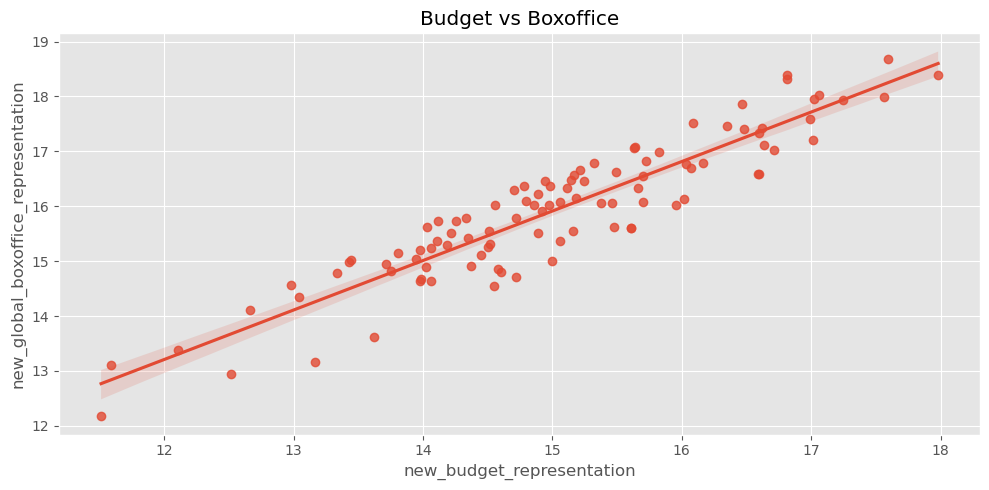

In [249]:
plt.figure(figsize=(10,5))
sns.regplot(data=df.head(100), x="new_budget_representation", y="new_global_boxoffice_representation")
plt.title("Budget vs Boxoffice")
plt.tight_layout()
plt.show()

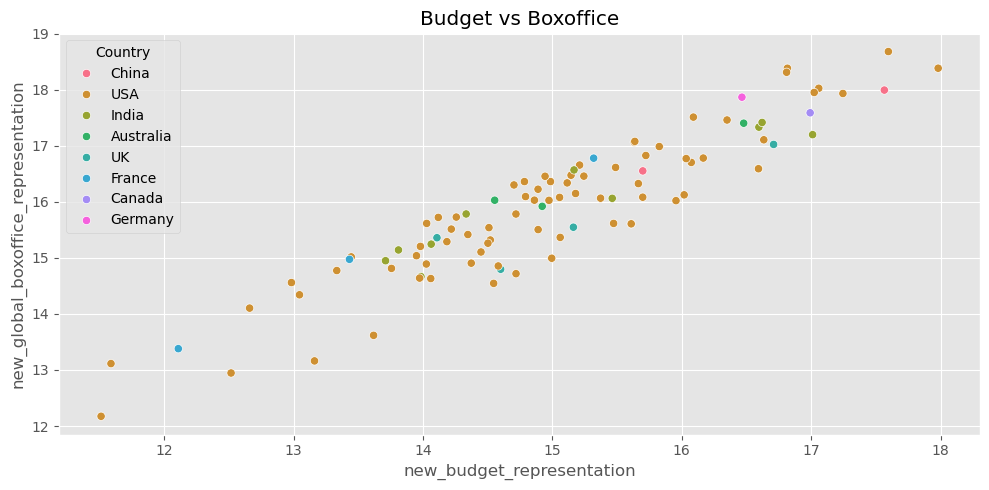

In [250]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.head(100), x="new_budget_representation", y="new_global_boxoffice_representation", hue="Country")
plt.title("Budget vs Boxoffice")
plt.tight_layout()
plt.show()

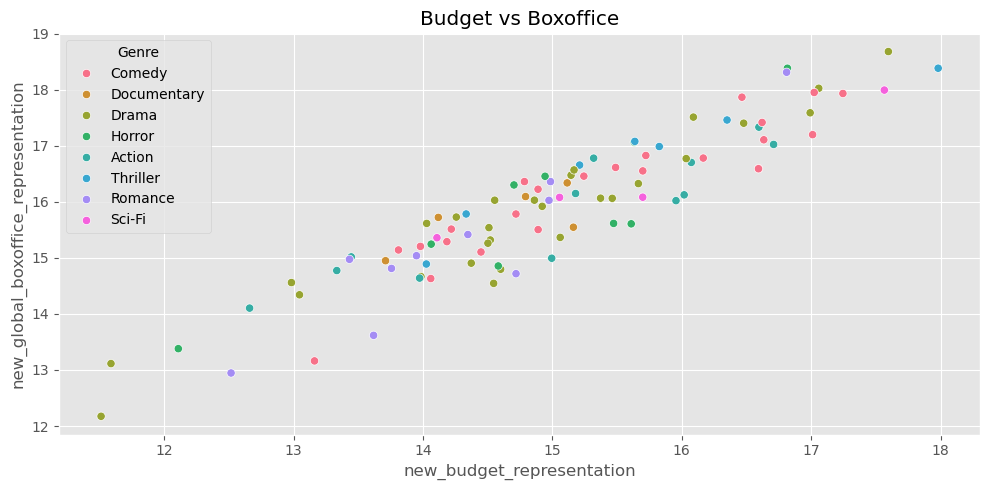

In [251]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.head(100), x="new_budget_representation", y="new_global_boxoffice_representation", hue="Genre")
plt.title("Budget vs Boxoffice")
plt.tight_layout()
plt.show()

### Observation

Movies with larger budgets generally tend to generate higher revenue, although there are several exceptions.

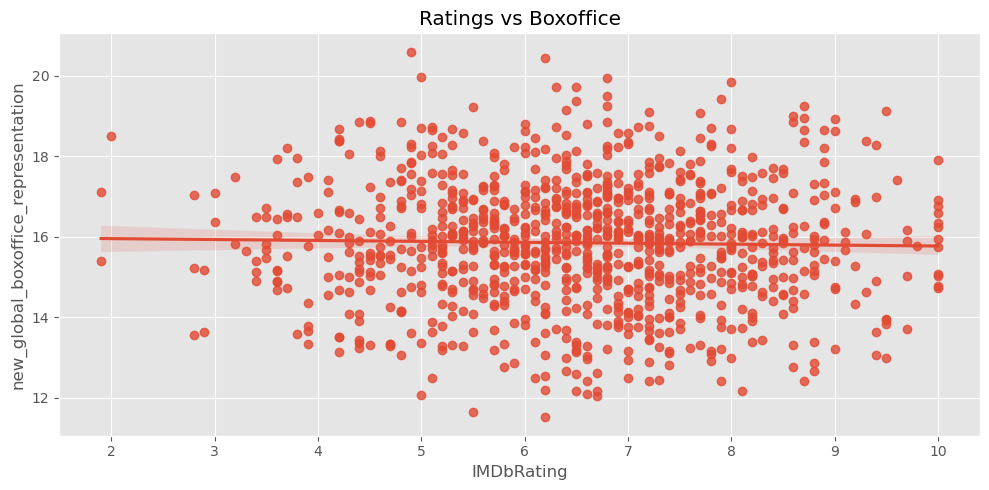

In [261]:
plt.figure(figsize=(10,5))
sns.regplot(data=df.head(1000), x="IMDbRating", y="new_global_boxoffice_representation")
plt.title("Ratings vs Boxoffice")
plt.tight_layout()
plt.show()

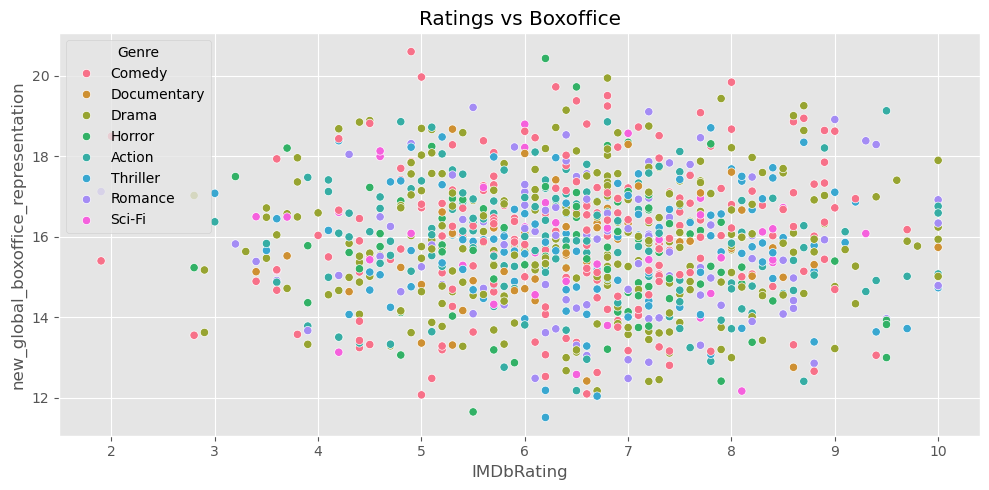

In [262]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.head(1000), x="IMDbRating", y="new_global_boxoffice_representation", hue="Genre")
plt.title("Ratings vs Boxoffice")
plt.tight_layout()
plt.show()

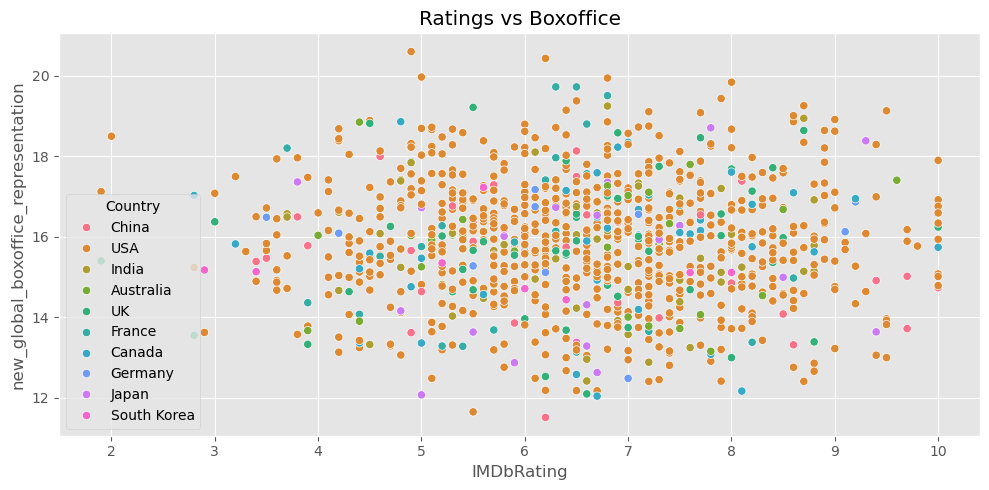

In [263]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.head(1000), x="IMDbRating", y="new_global_boxoffice_representation", hue="Country")
plt.title("Ratings vs Boxoffice")
plt.tight_layout()
plt.show()

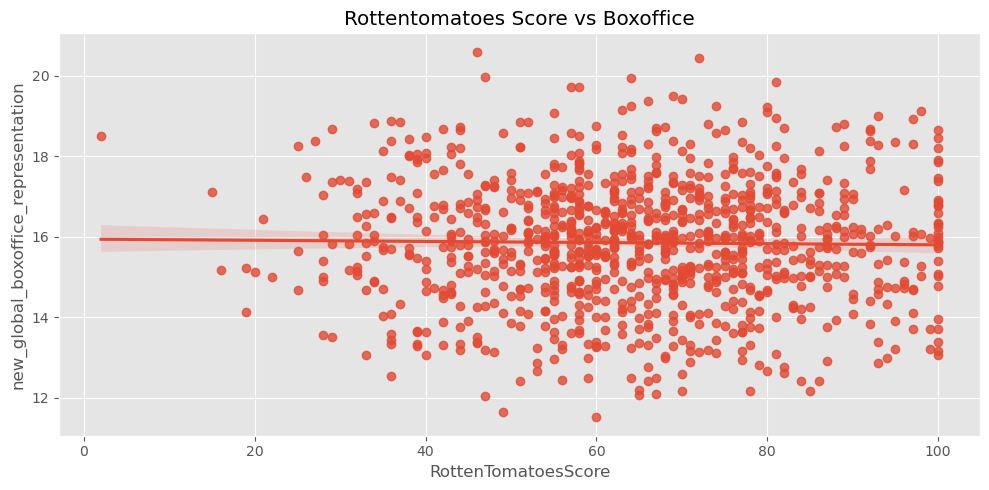

In [266]:
plt.figure(figsize=(10,5))
sns.regplot(data=df.head(1000), x="RottenTomatoesScore", y="new_global_boxoffice_representation")
plt.title("Rottentomatoes Score vs Boxoffice")
plt.tight_layout()
plt.show()

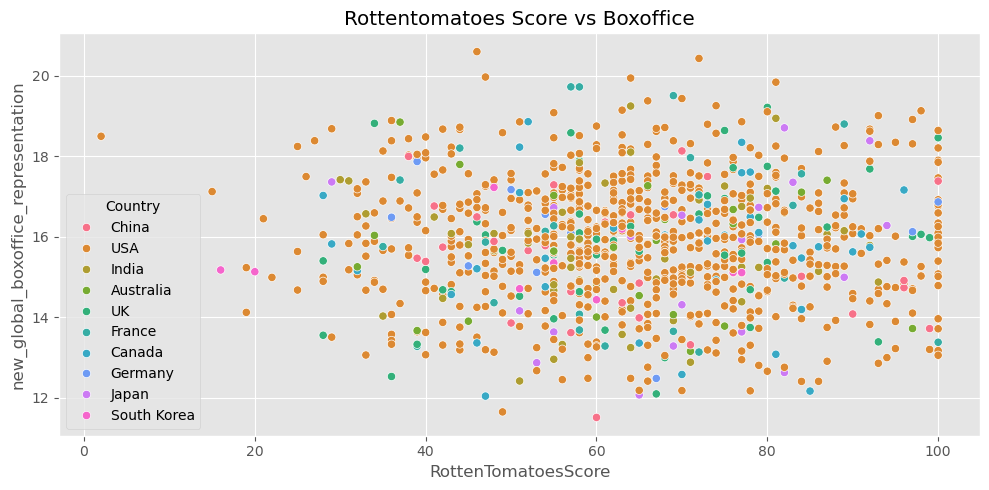

In [267]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.head(1000), x="RottenTomatoesScore", y="new_global_boxoffice_representation", hue="Country")
plt.title("Rottentomatoes Score vs Boxoffice")
plt.tight_layout()
plt.show()

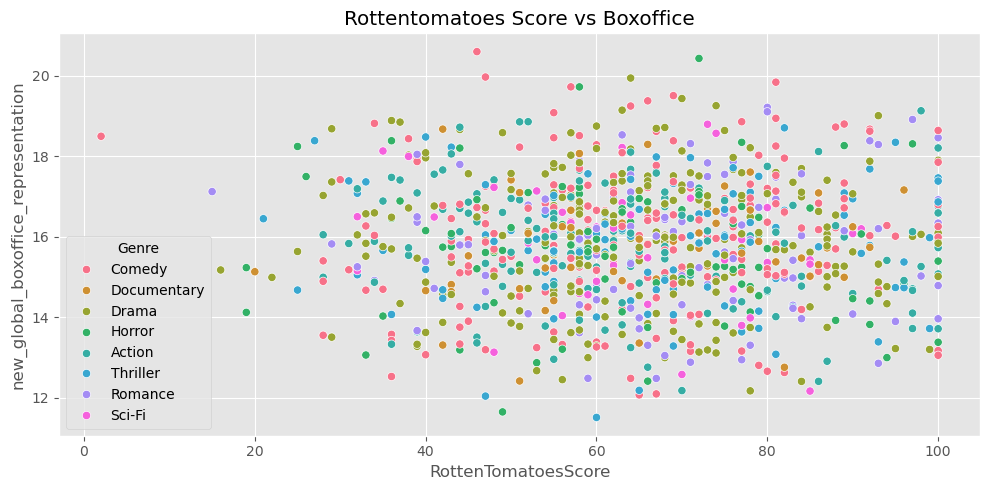

In [269]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.head(1000), x="RottenTomatoesScore", y="new_global_boxoffice_representation", hue="Genre")
plt.title("Rottentomatoes Score vs Boxoffice")
plt.tight_layout()
plt.show()

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables such as budget, ratings, revenue, profit, and ROI.

A correlation heatmap is used to visualize these relationships.

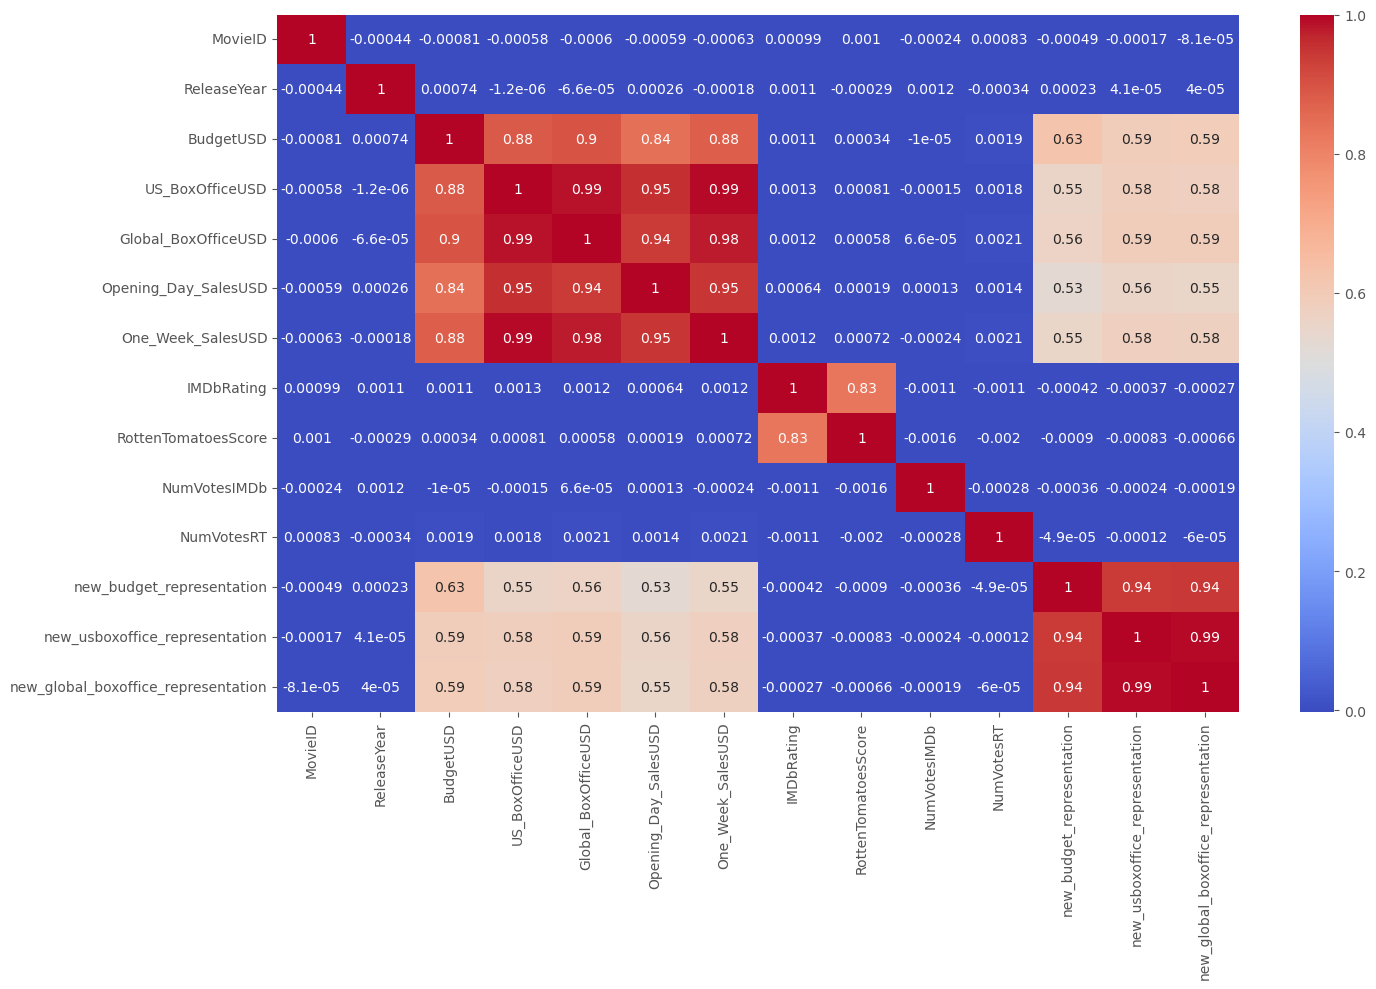

In [245]:
numeric_columns = df.select_dtypes(include=np.number)

corr_matrix = numeric_columns.corr()

plt.figure(figsize=(15,10))
sns.heatmap(data=corr_matrix, cbar=True, annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()


Revenue-related variables show positive relationships with budget, indicating that larger investments often lead to higher returns. Ratings show a weaker but still meaningful relationship with box office performance.

# Key Findings

- Higher budget movies generally earn higher global box office revenue.
- Revenue is concentrated among a relatively small number of blockbuster films.
- Certain genres consistently outperform others financially.
- Actor and director influence appears to impact movie performance.
- Ratings show a positive relationship with revenue.

# Business Recommendations

1. Focus investment on historically high-performing genres.
2. Consider actor and director track records when planning projects.
3. Balance budget allocation with expected returns.
4. Analyze successful high-ROI movies for future production strategies.
5. Use audience and critic ratings as supporting indicators during project evaluation.